# Regressão Linear

## 1. Regressão Linear Simples

A regressão linear simples busca modelar a relação entre duas variáveis, $x$ e $y$, em que $y = f(x)$. A relação, neste caso, é dada por:

$$
y = \theta_0 + \theta_1 x + \epsilon
$$

**Exemplo 1:** Desejamos realizar uma regressão linear para tentar prever uma medida quantitativa da progressão da diabetes um ano após o início do estudo. Para isso, vamos importar um conjunto de dados já disponível no banco ``sklearn.datasets``.

In [1]:
from sklearn.datasets import load_diabetes
import pandas as pd

data = load_diabetes(as_frame=True, scaled=False)

Para ver as features, basta fazer:

In [2]:
print(data.feature_names)

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


* `age`: Idade (em anos)
* `sex`: Gênero
* `bmi`: Indice de massa corporal
* `bp`: Pressão sanguínea média
* `s1`: Colesterol total (tc)
* `s2`: Colesterol LDL (ldl)
* `s3`: Colesterol HDL (hdl)
* `s4`: Colesterol Total / HDL (tch)
* `s5`: Nível de triglicerídeos (ltg)
* `s6`: Nível de açucar no sangue (glu)
* `target`: Medida quantitativa da progressão da doença um ano após o início do estudo.

Vamos visualizar o dataframe fazendo uma cópia para ``df``:

In [4]:
df = data.frame.copy()
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0


Vamos fazer uma regressão linear simples tal que a variável $x$ indicará o índice de massa corporal (`bmi`) e a variável $y$ será a medida quantitativa da progressão da doença um ano após o início do estudo.

In [5]:
X = df[["bmi"]]
y = df["target"]

Podemos visualizar essas duas variáveis utilizando um gráfico de dispersão:

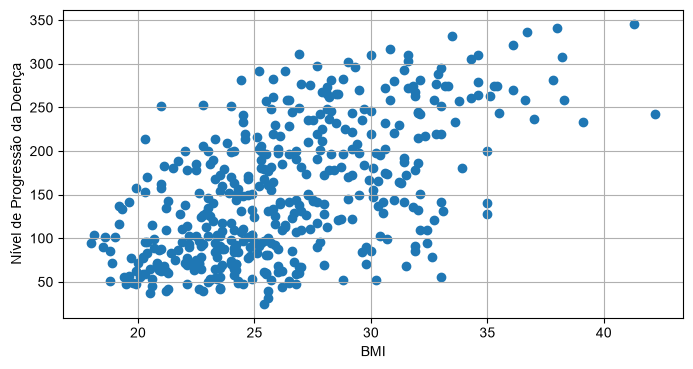

In [6]:
import matplotlib.pyplot as plt

#Muda a fonte dos Plots para Arial
plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams['mathtext.rm'] = "Arial"
plt.rcParams['mathtext.it'] = "Arial:italic"
plt.rcParams['mathtext.bf'] = "Arial:bold"
plt.rcParams['figure.figsize'] = (8, 4)

plt.scatter(X,y)
plt.ylabel('Nível de Progressão da Doença')
plt.xlabel('BMI')
plt.grid()
plt.show()

Vamos ajustar nosso modelo. Para isso, vamos dividir nosso conjunto de dados em dois sub-grupos: treinamento (que serão utilizados para ajustar os parâmetros) e teste (que será utilizado para verificar a capacidade de generalização do modelo). Para isso, vamos utilizar a função `train_test_split()`.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42
)

print(f"Tamanho do dataset = {X.shape[0]} amostras")
print(f"Quantidade de amostras de treinamento = {X_train.shape[0]} amostras")
print(f"Quantidade de amostras de teste = {X_test.shape[0]} amostras")

Tamanho do dataset = 442 amostras
Quantidade de amostras de treinamento = 353 amostras
Quantidade de amostras de teste = 89 amostras


A estimativa para o coeficiente angular $\hat{\theta}_1$ pode ser obtida pela fórmula:

$$
\hat{\theta}_1 = \frac{\displaystyle \sum_{i=1}^{N} \left(x^{(i)} - \bar{x}\right)\left(y^{(i)} - \bar{y}\right)}{\displaystyle \sum_{i=0}^{N-1} \left(x^{(i)} - \bar{x}\right)^2}
$$

In [8]:
import numpy as np

# Há necessidade de conversão para um vetor na numpy em virtude dos dados originais serem um dataframe
Xdata = X_train.to_numpy()[:,0]
ydata = y_train.to_numpy().T

t1 = np.sum((Xdata - np.mean(Xdata))*(ydata - np.mean(ydata)))/np.sum((Xdata - np.mean(Xdata))**2)
t1

np.float64(10.762790900604495)

Após calcular $\hat{\theta}_1$, $\hat{\theta}_0$ pode ser determinado como:

$$
\hat{\theta}_0 = \bar{y} - \hat{\theta}_1 \bar{x}
$$

In [9]:
t0 = np.mean(ydata) - t1*np.mean(Xdata)
t0

np.float64(-131.87377836094217)

Assim sendo, a melhor curva que ajusta ao modelo é:

$$
y = 10,76x - 131,87
$$

Podemos plotar essa curva sobre o conjunto de dados e verificar a tendência de linearidade.

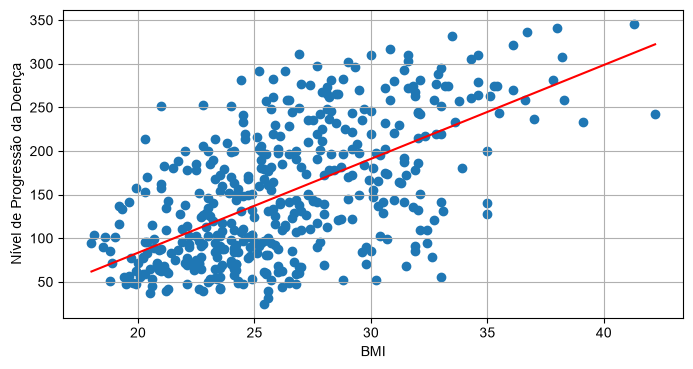

In [10]:
import numpy as np

X_curve = np.linspace(np.min(X),np.max(X),1000)
y_curve = t1*X_curve + t0

plt.scatter(X,y)
plt.plot(X_curve, y_curve,'r')
plt.ylabel('Nível de Progressão da Doença')
plt.xlabel('BMI')
plt.grid()
plt.show()

### Utilização da `sklearn`

A `sklearn` possui as funções para ajuste dos parâmetros de regressão. É o que faremos no exemplo a seguir.

**Exemplo 2:** Vamos ajustar nosso modelo de regressão linear, porém utilizando funções prontas da biblioteca `sklearn`. Para isso, podemos utilizar o modelo `LinearRegression()` e utilizar o método `fit()` para ajustar os parâmetros do modelo.

In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[10.76]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['bmi']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-131.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


O valor de $\theta_1$ é dado por:

In [12]:
t1 = model.coef_
t1

array([10.7627909])

O valor de $\theta_0$ é dado por:

In [13]:
t0 = model.intercept_
t0

np.float64(-131.87377836094223)

### Diagnóstico e Avaliação do Modelo

Aavaliação e o diagnóstico de um modelo de regressão linear são essenciais para garantir a qualidade do modelo. Neste caso utilizamos os dados disponíveis no conjunto de teste. Para isso podemos utilizar o MSE e $R^2$, Podemos utilizar as funções `mean_squared_error()` e `r2_score()` da biblioteca `sklearn` para calcular esses valores.

**Exemplo 3:** Vamos determinar o erro quadrático médio e o coeficiente de determinação para o modelo de regressão linear obtido no exemplo anterior.

In [14]:
from sklearn.metrics import mean_squared_error, r2_score

#O diagnóstico é sempre feito no conjunto de teste!
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erro quadrático médio (MSE): {mse:.2f}")
print(f"Coeficiente de determinação (R²): {r2:.2f}")

Erro quadrático médio (MSE): 4061.83
Coeficiente de determinação (R²): 0.23


## 2. Regressão Linear Múltipla

O modelo de regressão linear múltipla é uma extensão do modelo de regressão linear simples, onde a variável dependente é explicada por mais de uma variável independente. Neste caso, o modelo é descrito como:

$$
y = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_p x_p + \epsilon
$$

Os parâmetros do modelo podem ser estimados utilizando a equação normal:

$$
\mathbf{\Phi} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{Y}
$$

No contexto de regressão linear múltipla, as técnicas de normalização e padronização (*z-score*) são cruciais para garantir que o modelo seja treinado de forma eficiente e que seus coeficientes sejam interpretáveis.

**Exemplo 4:** Desejamos realizar uma regressão linear múltipla para tentar prever uma medida quantitativa da progressão da diabetes um ano após o início do estudo. Para isso, vamos importar um conjunto de dados já disponível no banco ``sklearn.datasets``.

In [15]:
from sklearn.datasets import load_diabetes
import pandas as pd
data = load_diabetes(as_frame=True, scaled=False)

In [17]:
df = data.frame.copy()
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0


Vamos utilizar todas as variáveis para a regressão linear. Desta forma, as variáveis `X` e `y` são dadas como:

In [18]:
X = df.drop(columns=["target"])
y = df["target"]

Veja que as variáveis possuem ordem de grandezas muito diferentes entre si. Podemos realizar uma normalização ou padronização para melhorar o desempenho do nosso algoritmo de treinamento. Para esse caso vamos realizar uma normalização entre 0 e 1.

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler  = MinMaxScaler(feature_range=(0, 1))
scaled  = scaler.fit_transform(X)
df_scaled = pd.DataFrame(scaled, columns=X.columns)
df_scaled

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.666667,1.0,0.582645,0.549296,0.294118,0.256972,0.207792,0.282087,0.562217,0.439394
1,0.483333,0.0,0.148760,0.352113,0.421569,0.306773,0.623377,0.141044,0.222437,0.166667
2,0.883333,1.0,0.516529,0.436620,0.289216,0.258964,0.246753,0.282087,0.496578,0.409091
3,0.083333,0.0,0.301653,0.309859,0.495098,0.447211,0.233766,0.423131,0.572923,0.469697
4,0.516667,0.0,0.206612,0.549296,0.465686,0.417331,0.389610,0.282087,0.362385,0.333333
...,...,...,...,...,...,...,...,...,...,...
437,0.683333,1.0,0.421488,0.704225,0.431373,0.359562,0.259740,0.282087,0.605672,0.530303
438,0.466667,1.0,0.285124,0.183099,0.627451,0.619522,0.259740,0.423131,0.415810,0.666667
439,0.683333,1.0,0.285124,0.530563,0.318627,0.323705,0.272727,0.249647,0.305030,0.560606
440,0.283333,0.0,0.495868,0.464789,0.509804,0.416335,0.259740,0.393512,0.657026,0.409091


Após isso, vamos dividir nosso conjunto de dados em conjunto de treinamento e conjunto de validação.

In [20]:
from sklearn.model_selection import train_test_split

X = df_scaled
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.3, random_state=42
)

print(f"Tamanho do dataset = {X.shape[0]} amostras")
print(f"Quantidade de amostras de treinamento = {X_train.shape[0]} amostras")
print(f"Quantidade de amostras de teste = {X_test.shape[0]} amostras")

Tamanho do dataset = 442 amostras
Quantidade de amostras de treinamento = 309 amostras
Quantidade de amostras de teste = 133 amostras


E por fim, vamos utilizar o modelo de regressão linear disponibilizado na `sklearn`. Utilizaremos o mesmo método `fit()` para ajustar os parâmetros do modelo.

In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 6.38,-24.95,142.49,..., 75.36,171.21, 11.31]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['age','sex','bmi',...,'s4','s5','s6']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.8874
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,10


Os coeficientes $\theta_1, \theta_2, \dots, \theta_p$ podem ser determinados como:

In [22]:
theta = model.coef_
theta

array([   6.37597963,  -24.94631999,  142.49164186,   94.94103001,
       -253.17501262,  159.32689804,   34.34557573,   75.35836358,
        171.20845644,   11.31152349])

Já o coeficiente $\theta_0$ é obtido como:

In [23]:
theta_0 = model.intercept_
theta_0

np.float64(-0.8873660950040687)

Portanto, a equação que descreve esse modelo de regressão é dado como:

$$\begin{aligned}
\hat{y} = -0.8873 &+ 6.37x_1 - 24.94x_2 + 142.49x_3 + 94.94x_4 - 253.17x_5 \\
&+ 159.32x_6 + 34.34x_7 + 75.35x_8 + 171.20x_9 + 11.31x_{10}
\end{aligned}$$

$x_1, x_2, \dots, x_{10}$ representam as features na ordem em que aparecem no dataframe (idade, sexo, bmi, ...). Podemos agora determinar o erro quadrático médio e o coeficiente de determinação para essa regressão:

In [24]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erro quadrático médio (MSE): {mse:.2f}")
print(f"Coeficiente de determinação (R²): {r2:.2f}")

Erro quadrático médio (MSE): 2821.75
Coeficiente de determinação (R²): 0.48


Por fim, vamos plotar um gráfico de dispersão que relaciona o valor previsto em função do valor real do conjunto de treinamento.

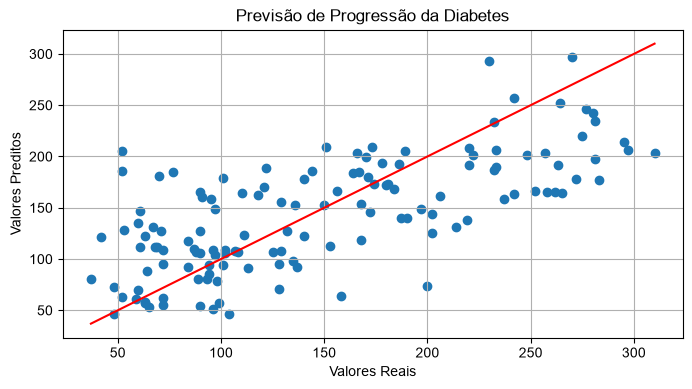

In [25]:
import matplotlib.pyplot as plt

y_test_min = np.min(y_test)
y_test_max = np.max(y_test)

y_ideal = np.linspace(y_test_min, y_test_max, 1000)

plt.plot(y_ideal, y_ideal, 'r')
plt.scatter(y_test, y_pred)
plt.xlabel("Valores Reais")
plt.ylabel("Valores Preditos")
plt.title("Previsão de Progressão da Diabetes")
plt.grid(True)
plt.show()

## 3. Regularização

Em modelos de regressão linear, o objetivo é minimizar a soma dos quadrados dos resíduos (erro). No entanto, se o modelo for muito complexo (muitas variáveis ou coeficientes muito altos), ele pode "decorar" o ruído dos dados de treino (*overfitting*).

A regularização adiciona uma penalidade ao tamanho dos coeficientes. Assim, o modelo é forçado a manter os pesos baixos, priorizando apenas as variáveis mais importantes.

**Exemplo 5:** Desejamos realizar uma regressão linear múltipla com regularização para tentar prever uma medida quantitativa da progressão da diabetes um ano após o início do estudo. Para isso, vamos importar um conjunto de dados já disponível no banco `sklearn.datasets`.

Vamos inicialmente importar nosso conjunto de dados.

In [26]:
from sklearn.linear_model import Ridge, Lasso, LinearRegression

diabetes = load_diabetes(as_frame=True, scaled=False)
df = diabetes.frame.copy()
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0


In [28]:
X, y = df.drop(columns=["target"]), df["target"]

scaler   = MinMaxScaler(feature_range=(0, 1))
scaled   = scaler.fit_transform(X)
X_scaled = pd.DataFrame(scaled, columns=X.columns)
X_scaled.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.666667,1.0,0.582645,0.549296,0.294118,0.256972,0.207792,0.282087,0.562217,0.439394
1,0.483333,0.0,0.148760,0.352113,0.421569,0.306773,0.623377,0.141044,0.222437,0.166667
2,0.883333,1.0,0.516529,0.436620,0.289216,0.258964,0.246753,0.282087,0.496578,0.409091
3,0.083333,0.0,0.301653,0.309859,0.495098,0.447211,0.233766,0.423131,0.572923,0.469697
4,0.516667,0.0,0.206612,0.549296,0.465686,0.417331,0.389610,0.282087,0.362385,0.333333


Criando o nosso conjunto de teste e de treinamento:

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Tamanho do dataset = {X.shape[0]} amostras")
print(f"Quantidade de amostras de treinamento = {X_train.shape[0]} amostras")
print(f"Quantidade de amostras de teste = {X_test.shape[0]} amostras")

Tamanho do dataset = 442 amostras
Quantidade de amostras de treinamento = 353 amostras
Quantidade de amostras de teste = 89 amostras


Vamos agora criar nossos modelos de regressão com regularização utilizando as funções `Ridge()` e `Lasso()`. Essas funções recebem, como argumento, o hiperparâmetro que controla a quantidade de regularização a ser aplicado no modelo.

In [30]:
ridge_regression = Ridge(alpha=1.5)
lasso_regression = Lasso(alpha=0.2)
linear_regression = LinearRegression()

ridge_regression.fit(X_train, y_train)
lasso_regression.fit(X_train, y_train)
linear_regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 8.26,-23.06,141.48,..., 72.03,191.19, 13.31]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['age','sex','bmi',...,'s4','s5','s6']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-9.056
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,10


Podemos verificar os parâmetros gerados pelo processo de treinamento do modelo:

In [31]:
t0_ridge, t1_ridge = ridge_regression.intercept_, ridge_regression.coef_
t0_lasso, t1_lasso = lasso_regression.intercept_, lasso_regression.coef_
t0, t1 = linear_regression.intercept_, linear_regression.coef_

print(f"Regressão Linear: \n Intercepto (theta0) = {t0:.4f}")
print(f"Coeficientes (theta1...) = {t1}\n")

print(f"Ridge (L2): \n Intercepto = {t0_ridge:.4f}")
print(f"Coeficientes = {t1_ridge}\n")

print(f"Lasso (L1): \n Intercepto = {t0_lasso:.4f}")
print(f"Coeficientes = {t1_lasso}")

Regressão Linear: 
 Intercepto (theta0) = -9.0560
Coeficientes (theta1...) = [   8.2612689   -23.06446772  141.48197617   84.9935688  -261.46368693
  162.87932677   46.32729542   72.03113268  191.18672297   13.3055384 ]

Ridge (L2): 
 Intercepto = 45.6563
Coeficientes = [ 10.14102365 -22.09938025 130.20616812  79.64013615 -33.40940968
 -23.77740686 -53.21584567  41.84833258 101.76306148  21.60676166]

Lasso (L1): 
 Intercepto = 43.2035
Coeficientes = [  3.94789617 -19.99418015 143.84385211  79.86077649 -46.31102921
  -0.         -55.94409864  18.44951639 121.89921848  11.28275428]


E por fim, vamos calcular o coeficiente de determinação e o erro quadrático médio dos modelos:

In [32]:
y_pred_ridge = ridge_regression.predict(X_test)
y_pred_lasso = lasso_regression.predict(X_test)
y_pred_linear = linear_regression.predict(X_test)

print("--- Resultados Ridge (L2) ---")
print(f"R2 Score: {r2_score(y_test, y_pred_ridge):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_ridge):.4f}")

print("\n--- Resultados Lasso (L1) ---")
print(f"R2 Score: {r2_score(y_test, y_pred_lasso):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_lasso):.4f}")

print("\n--- Resultados Regressão Linear ---")
print(f"R2 Score: {r2_score(y_test, y_pred_linear):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_linear):.4f}")

--- Resultados Ridge (L2) ---
R2 Score: 0.4608
MSE: 2856.8407

--- Resultados Lasso (L1) ---
R2 Score: 0.4676
MSE: 2820.6255

--- Resultados Regressão Linear ---
R2 Score: 0.4526
MSE: 2900.1936
